## Basic plotting of temperature and wind barbs using `uxarray` and `matplotlib` (Use environment `NPL 2025b`)

This notebook shows how to easily analyze and plot data (t2m and wind barbs shown here) from any MPAS mesh. Make sure you use the environment `NPL 2025b`


In [1]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np
import xarray as xr
import uxarray as ux
import cartopy.feature as cfeature
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from scipy.interpolate import griddata
import glob

I didn't love the matplotlib colorbar options for temperature so I grabbed the following colormap from this github

https://github.com/blaylockbk/pyBKB_v2/blob/master/demos/National_Weather_Service_Standard_Color_Curves.ipynb

You can also always use whatever you want, such as `cmap="turbo"`

In [2]:
# Color tuple for every bin
C = np.array([[145,0,63],[206,18,86],[231,41,138],[223,101,176],[255,115,223],[255,190,232],
              [255,255,255],[218,218,235],[188,189,220],[158,154,200],[117,107,177],[84,39,143],
              [13,0,125],[13,61,156],[0,102,194],[41,158,255],[74,199,255],[115,215,255],
              [173,255,255],[48,207,194],[0,153,150],[18,87,87],[6,109,44],[49,163,84],
              [116,196,118],[161,217,155],[211,255,190],[255,255,179],[255,237,160],[254,209,118],
              [254,174,42],[253,141,60],[252,78,42],[227,26,28],[177,0,38],[128,0,38],[89,0,66],[40,0,40]])/255.

norm = np.linspace(0,1,len(C))
COLORS = []
for i, n in enumerate(norm):
    COLORS.append((n,C[i]))

cmap = colors.LinearSegmentedColormap.from_list("Temperature",COLORS)

Set path for data and load in using `ux.open_mfdataset` from uxarray.
Also set what date/time we want to look at.

In [3]:
base_path = "../240-48km_variable/"
files = f"{base_path}diag*nc"
grid_path = f"{base_path}SouthAmerica.grid.nc"
uxds = ux.open_mfdataset(grid_path,files,combine="nested",concat_dim="Time")
plot_time = "2014-09-13 00"
ms2kts = 1.94384

Some really basic analysis showing daily mean/max/min calculations, selecting our time slice and converting to Celcius.

In [4]:
t2max = uxds["t2m"].resample(Time="D",closed="right").max().sel(Time=plot_time)-273.15
t2min = uxds["t2m"].resample(Time="D",closed="right").min().sel(Time=plot_time)-273.15
t2avg = uxds["t2m"].resample(Time="D",closed="right").mean().sel(Time=plot_time)-273.15

Plot the global mesh using `to_raster` from `uxarray` and `imshow` from `matplotlib` on a Robinson projection.

`imshow` sets the limits automatically, but if you want to set them just add `clim=(-50,50)` to the imshow command.

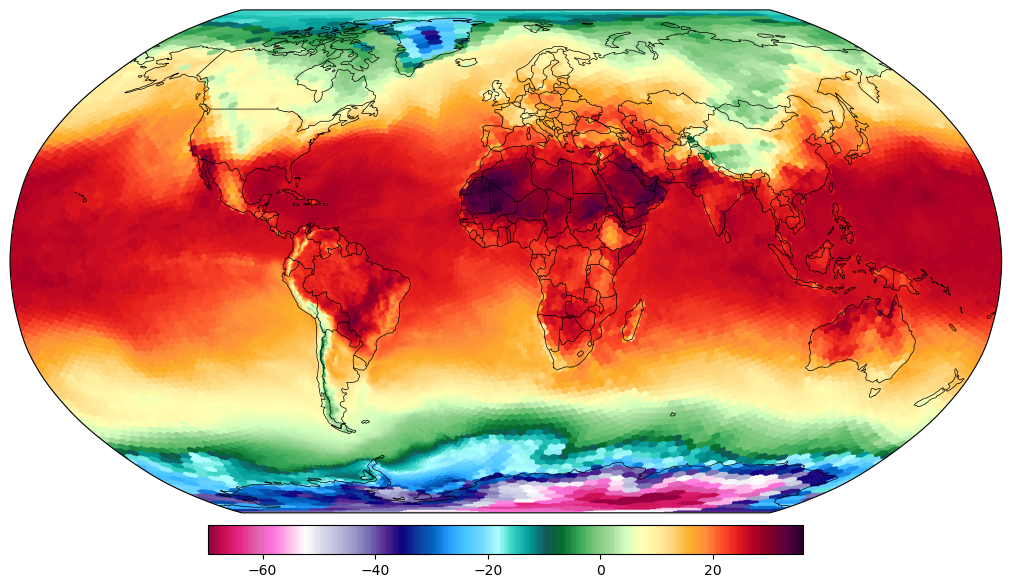

In [5]:
projection = ccrs.Robinson()
fig, ax = plt.subplots(figsize=(10,10), subplot_kw={"projection": projection},facecolor="w",layout="constrained")
ax.set_global()

raster = t2avg.to_raster(ax=ax)
im = ax.imshow(raster,origin="lower",extent=ax.get_xlim() + ax.get_ylim(),cmap=cmap,zorder=1)
ax.add_feature(cfeature.COASTLINE.with_scale("110m"),linewidth=0.5,edgecolor="black")
ax.add_feature(cfeature.BORDERS.with_scale("110m"),linewidth=0.5,edgecolor="black")

cbar = fig.colorbar(im,ax=ax,orientation="horizontal",pad=0.01,shrink=0.6)

#plt.savefig("temp_global.jpg", bbox_inches="tight", dpi=300)
plt.show()

Lets zoom in and look at a regional area (South America here, but you can change it to wherever you want). Also, set some latlon ticks and add gridlines.

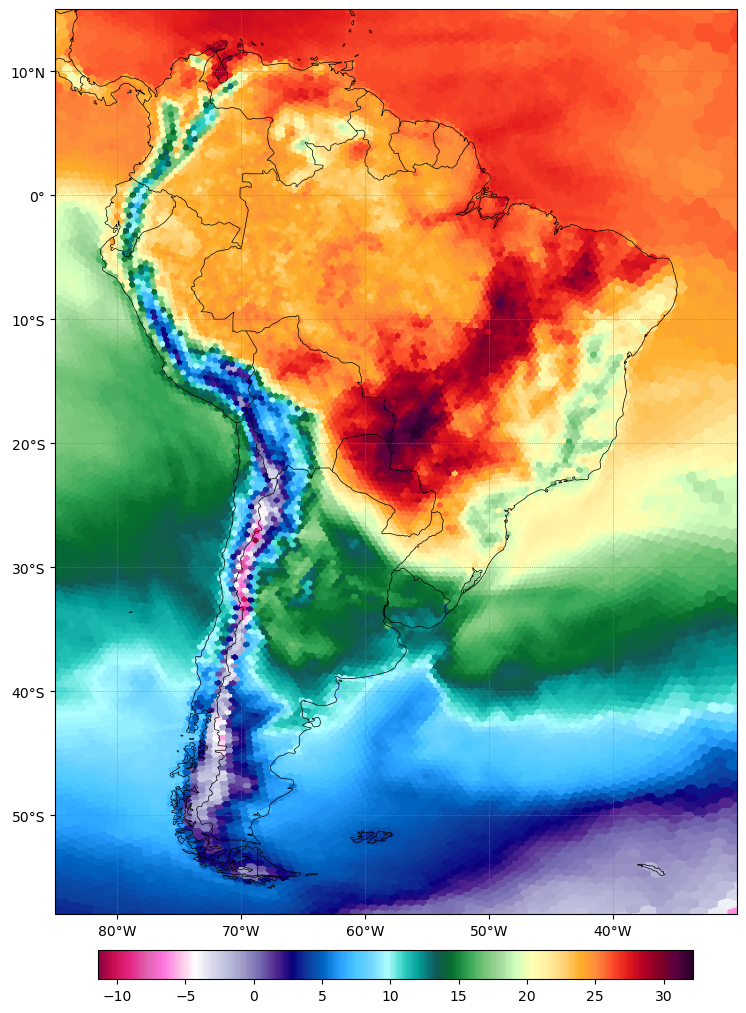

In [6]:
minLon, maxLon = -85, -30
minLat, maxLat = -58, 15
projection = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(10,10),subplot_kw={"projection": projection},facecolor="w",layout="constrained")
ax.set_extent([minLon,maxLon,minLat,maxLat],crs=ccrs.PlateCarree())

raster = t2avg.to_raster(ax=ax)
im = ax.imshow(raster,origin="lower",extent=ax.get_xlim() + ax.get_ylim(),cmap=cmap,zorder=1)
ax.add_feature(cfeature.COASTLINE.with_scale("50m"),linewidth=0.5, edgecolor="black")
ax.add_feature(cfeature.BORDERS.with_scale("50m"),linewidth=0.5, edgecolor="black")

# Add lats and lons
step = 10  # Change to 5 if you want ticks every 5 degrees
start_lat = np.ceil(minLat / step) * step
start_lon = np.ceil(minLon / step) * step
ax.set_yticks(np.arange(start_lat,maxLat,step),crs=projection)
ax.yaxis.set_major_formatter(LatitudeFormatter()); ax.tick_params(axis="y",labelsize=10)
ax.set_xticks(np.arange(start_lon,maxLon,step),crs=projection)
ax.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=True)); ax.tick_params(axis="x",labelsize=10)
ax.grid(True,linestyle=":",linewidth=0.5,color="gray")

cbar = fig.colorbar(im,ax=ax,orientation="horizontal",pad=0.01,shrink=0.6)

#plt.savefig("temp_samerica.jpg", bbox_inches="tight", dpi=300)
plt.show()

Now I want to look at a specific time slice and add windbarbs. It's also quite easy to change projections!

In [7]:
t2_time = uxds["t2m"].sel(Time=plot_time)-273.15
u10_time = uxds["u10"].sel(Time=plot_time).values.squeeze()*ms2kts
v10_time = uxds["v10"].sel(Time=plot_time).values.squeeze()*ms2kts

To make the wind barbs look evenly spaced on the map, we need to interpolate to a 2d grid using `griddata`. This is very easy and fast!

In [8]:
# Interpolation for wind barbs
minLat, maxLat = -90, 90
minLon, maxLon = -180, 180
barb_res = 8.5 # Degree spacing of barbs
lon2d, lat2d = np.meshgrid(np.arange(minLon,maxLon,barb_res),np.arange(minLat,maxLat,barb_res))

lons = np.where(uxds.uxgrid.face_lon.values > 180,uxds.uxgrid.face_lon.values - 360,uxds.uxgrid.face_lon.values)
lats = uxds.uxgrid.face_lat.values

u_interp = griddata((lons,lats),u10_time.flatten(),(lon2d,lat2d),method='linear')
v_interp = griddata((lons,lats),v10_time.flatten(),(lon2d,lat2d),method='linear')

Panel plot comparing `Robinson` and `PlateCarree`

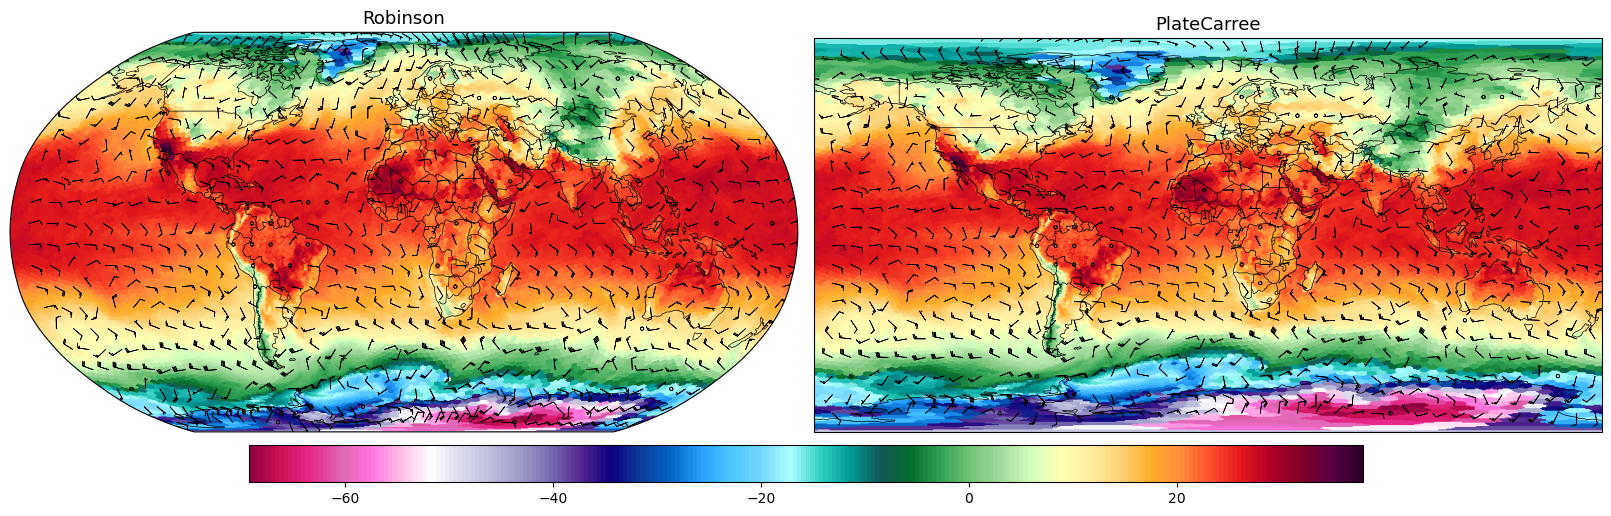

In [9]:
fig = plt.figure(figsize=(16, 6), facecolor="w", layout="constrained")

ax1 = fig.add_subplot(1,2,1,projection=ccrs.Robinson())
ax1.set_global()
raster1 = t2_time.to_raster(ax=ax1)
im1 = ax1.imshow(raster1,origin="lower",extent=ax1.get_xlim() + ax1.get_ylim(),cmap=cmap,zorder=1)
ax1.set_title("Robinson",fontsize=13)

ax2 = fig.add_subplot(1,2,2,projection=ccrs.PlateCarree())
ax2.set_global()
raster2 = t2_time.to_raster(ax=ax2)
im2 = ax2.imshow(raster2,origin="lower",extent=ax2.get_xlim() + ax2.get_ylim(),cmap=cmap,zorder=1)
ax2.set_title("PlateCarree",fontsize=13)

for ax in (ax1, ax2):
    ax.barbs(lon2d,lat2d,u_interp,v_interp,length=4,linewidth=0.5,color="black",transform=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE.with_scale("110m"),linewidth=0.5,edgecolor="black")
    ax.add_feature(cfeature.BORDERS.with_scale("110m"),linewidth=0.5,edgecolor="black")

cbar = fig.colorbar(im1,ax=[ax1,ax2],orientation="horizontal",pad=0.02,shrink=0.7,aspect=30)

#plt.savefig("temp_barbs_global.jpg", bbox_inches="tight", dpi=300)
plt.show()

Add windbarbs to the regional plot! Same exact method as we used for the global mesh.

In [10]:
# Interpolation for wind barbs
minLon, maxLon = -85, -30
minLat, maxLat = -58, 15
barb_res = 1.5 # Degree spacing of barbs
lon2d, lat2d = np.meshgrid(np.arange(minLon,maxLon,barb_res),np.arange(minLat,maxLat,barb_res))

lons = np.where(uxds.uxgrid.face_lon.values > 180, uxds.uxgrid.face_lon.values - 360, uxds.uxgrid.face_lon.values)
lats = uxds.uxgrid.face_lat.values

u_interp = griddata((lons,lats),u10_time.flatten(),(lon2d,lat2d),method='linear')
v_interp = griddata((lons,lats),v10_time.flatten(),(lon2d,lat2d),method='linear')

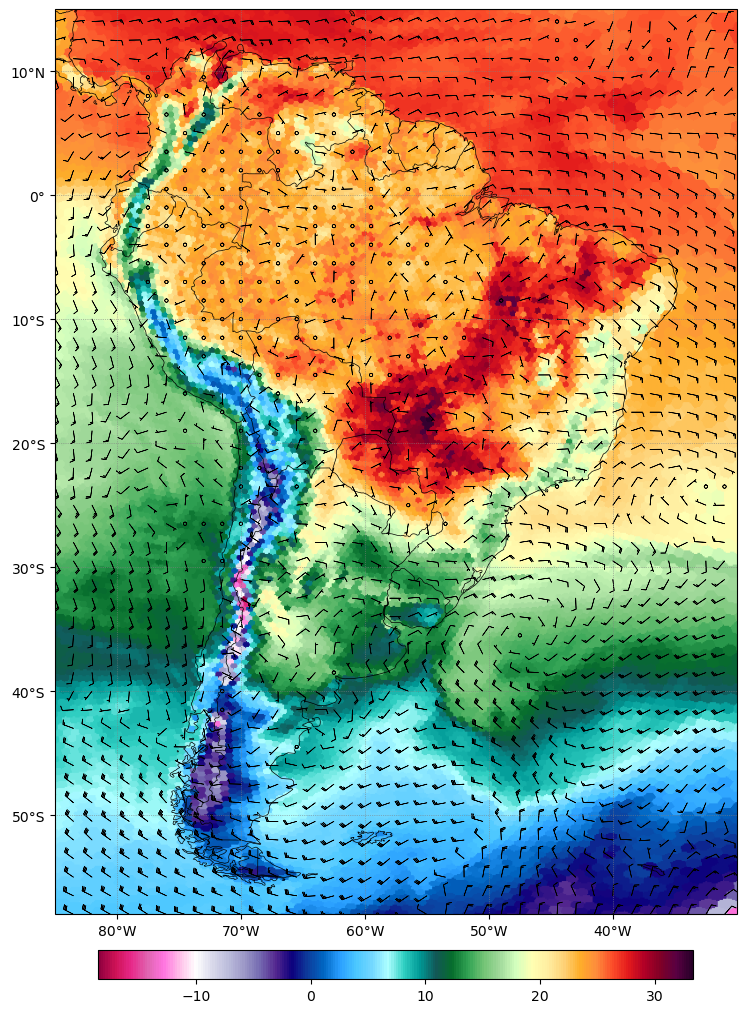

In [11]:
projection = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(10,10), subplot_kw={"projection": projection},facecolor="w",layout="constrained")
ax.set_extent([minLon,maxLon,minLat,maxLat],crs=ccrs.PlateCarree())

raster = t2_time.to_raster(ax=ax)
im = ax.imshow(raster,origin="lower",extent=ax.get_xlim() + ax.get_ylim(),cmap=cmap,zorder=1)
ax.barbs(lon2d,lat2d,u_interp,v_interp,length=4,linewidth=0.5,color="black",transform=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE.with_scale("50m"),linewidth=0.5, edgecolor="black")
ax.add_feature(cfeature.BORDERS.with_scale("50m"),linewidth=0.5, edgecolor="black")

# Add lats and lons
step = 10  # Change to 5 if you want ticks every 5 degrees
start_lat = np.ceil(minLat / step) * step
start_lon = np.ceil(minLon / step) * step
ax.set_yticks(np.arange(start_lat,maxLat,step),crs=projection)
ax.yaxis.set_major_formatter(LatitudeFormatter()); ax.tick_params(axis="y",labelsize=10)
ax.set_xticks(np.arange(start_lon,maxLon,step),crs=projection)
ax.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=True)); ax.tick_params(axis="x",labelsize=10)
ax.grid(True,linestyle=":",linewidth=0.5,color="gray")

cbar = fig.colorbar(im,ax=ax,orientation="horizontal",pad=0.01,shrink=0.6)

#plt.savefig("temp_barbs_samerica.jpg", bbox_inches="tight", dpi=300)
plt.show()